#### Libraries

In [1]:
!pip install scapy -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.1 MB/s eta 0:00:00


In [2]:
import urllib.request
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scapy.all import IP, ICMP, sr
from geopy.distance import distance
import io

####1. Identifying the Local Machine

In [3]:
# Get my IP and location
ip = urllib.request.urlopen("http://api.ipify.org/").read().decode("UTF-8")
print(f"My IP: {ip}")

# Request my lat, lon specifically for geopy distance calculations
info = json.loads(urllib.request.urlopen("http://ip-api.com/json/"+ip).read())

my_lat = info['lat']
my_lon = info['lon']

print(f"City: {info['city']}")
print(f"Country: {info['country']}")
print(f"Coordinates: {my_lat}, {my_lon}")

My IP: 34.80.231.35
City: Taipei
Country: Taiwan
Coordinates: 25.0329, 121.5654


####2. Read Target Servers from CSV

In [44]:
df_servers = pd.read_csv("servers.csv")

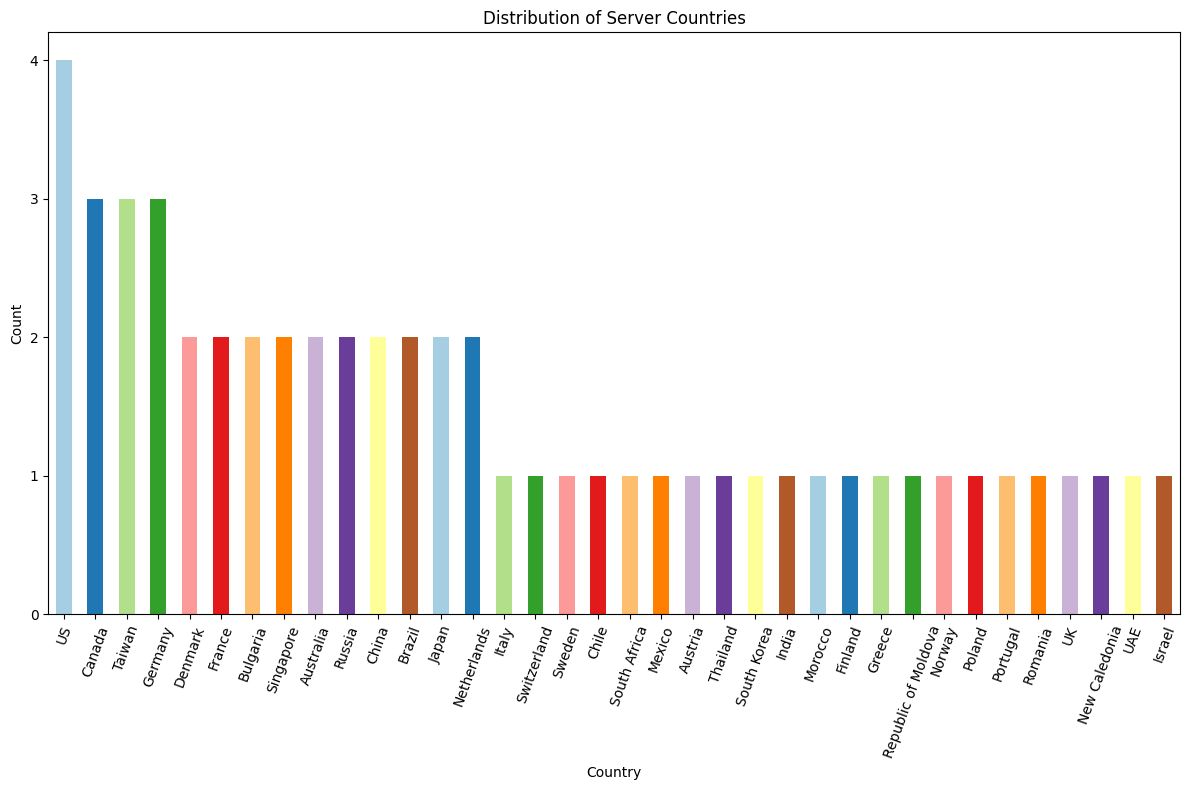

In [79]:
df_servers["country"].value_counts().plot(
    kind='bar',
    figsize=(12, 8),
    rot=70,
    color=plt.cm.Paired.colors
)

plt.title("Distribution of Server Countries")
plt.xlabel("Country")
plt.yticks(range(0, df_servers["country"].value_counts().max() + 1, 1))
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### 3. Measurement Functions

In [45]:
def get_target_coords(hostname):
    """Fetches the lat/lon of a target hostname."""
    try:
        time.sleep(0.5)
        info = json.loads(urllib.request.urlopen(f"http://ip-api.com/json/{hostname}").read())
        if info['status'] == 'success':
            return info['lat'], info['lon']
    except Exception as e: # Print if Error Happend from location API
        print(f"Error locating {hostname}: {e}")
    return None, None

def get_scapy_avg_rtt(target, count=10, timeout=2):
    """Uses scapy to send ICMP packets and calculate Average RTT."""
    rtts = []
    for x in range(count):
        # Create ICMP Packet
        pck = IP(dst=target)/ICMP()
        # Added timeout so unreachable hosts don't hang the loop
        ans, unans = sr(pck, verbose=False, timeout=timeout)

        if len(ans) > 0:
            query = ans[0][0]
            answ = ans[0][1]
            # RTT in milliseconds
            rtt = (answ.time - query.sent_time) * 1000
            rtts.append(rtt)

    if rtts:
        return sum(rtts) / len(rtts)
    return None

####4. Executing Measurements

In [46]:
results = []

print("Starting active network measurements")
for index, row in df_servers.iterrows():
    host = row['hostname']
    print(f"Testing {index+1}/{len(df_servers)} {host}:")

    # Get Server Location
    t_lat, t_lon = get_target_coords(host)
    if t_lat is None:
        continue

    # Calculate Distance in km
    dist_km = distance((my_lat, my_lon), (t_lat, t_lon)).km

    # Measure Average RTT (5 packets)
    avg_rtt = get_scapy_avg_rtt(host, count=5)

    if avg_rtt is not None:
        results.append({
            'country': row['country'],
            'hostname': host,
            'distance_km': dist_km,
            'avg_rtt_ms': avg_rtt
        })
        print(f"\t-> Distance: {dist_km:.2f} km | Avg RTT: {avg_rtt:.4f} ms")
    else:
        print(f"\t-> Failed to reach {host}")

# Convert List of data to DataFrame
df_results = pd.DataFrame(results)
print("Measurements Done.")

Starting active network measurements
Testing 1/56 garr.it:
	-> Distance: 9627.72 km | Avg RTT: 210.9353 ms
Testing 2/56 ethz.ch:
	-> Distance: 9572.05 km | Avg RTT: 203.8693 ms
Testing 3/56 kth.se:
	-> Distance: 8372.45 km | Avg RTT: 220.7836 ms
Testing 4/56 mcgill.ca:
	-> Failed to reach mcgill.ca
Testing 5/56 unam.mx:
	-> Distance: 13413.78 km | Avg RTT: 181.0996 ms
Testing 6/56 nic.cl:
	-> Distance: 18512.35 km | Avg RTT: 260.9118 ms
Testing 7/56 sanren.ac.za:
	-> Distance: 12654.60 km | Avg RTT: 237.5082 ms
Testing 8/56 rnp.br:
	-> Distance: 12045.26 km | Avg RTT: 4.3351 ms
Testing 9/56 sg.pool.ntp.org:
	-> Distance: 3240.78 km | Avg RTT: 3.8252 ms
Testing 10/56 www.ntu.edu.tw:
	-> Failed to reach www.ntu.edu.tw
Testing 11/56 kantei.go.jp:
	-> Distance: 12667.45 km | Avg RTT: 3.6511 ms
Testing 12/56 nla.gov.au:
	-> Distance: 7280.26 km | Avg RTT: 135.3196 ms
Testing 13/56 mirror.csclub.uwaterloo.ca:
	-> Failed to reach mirror.csclub.uwaterloo.ca
Testing 14/56 mirror.techrich.hk:
	-

In [81]:
# Save Results
df_results.to_csv("results.csv", index=False)

####5. Linear Fitting and Plotting

Estimated average RTT per km (slope): 0.01075 ms/km
Estimated baseline delay (intercept): 82.20 ms



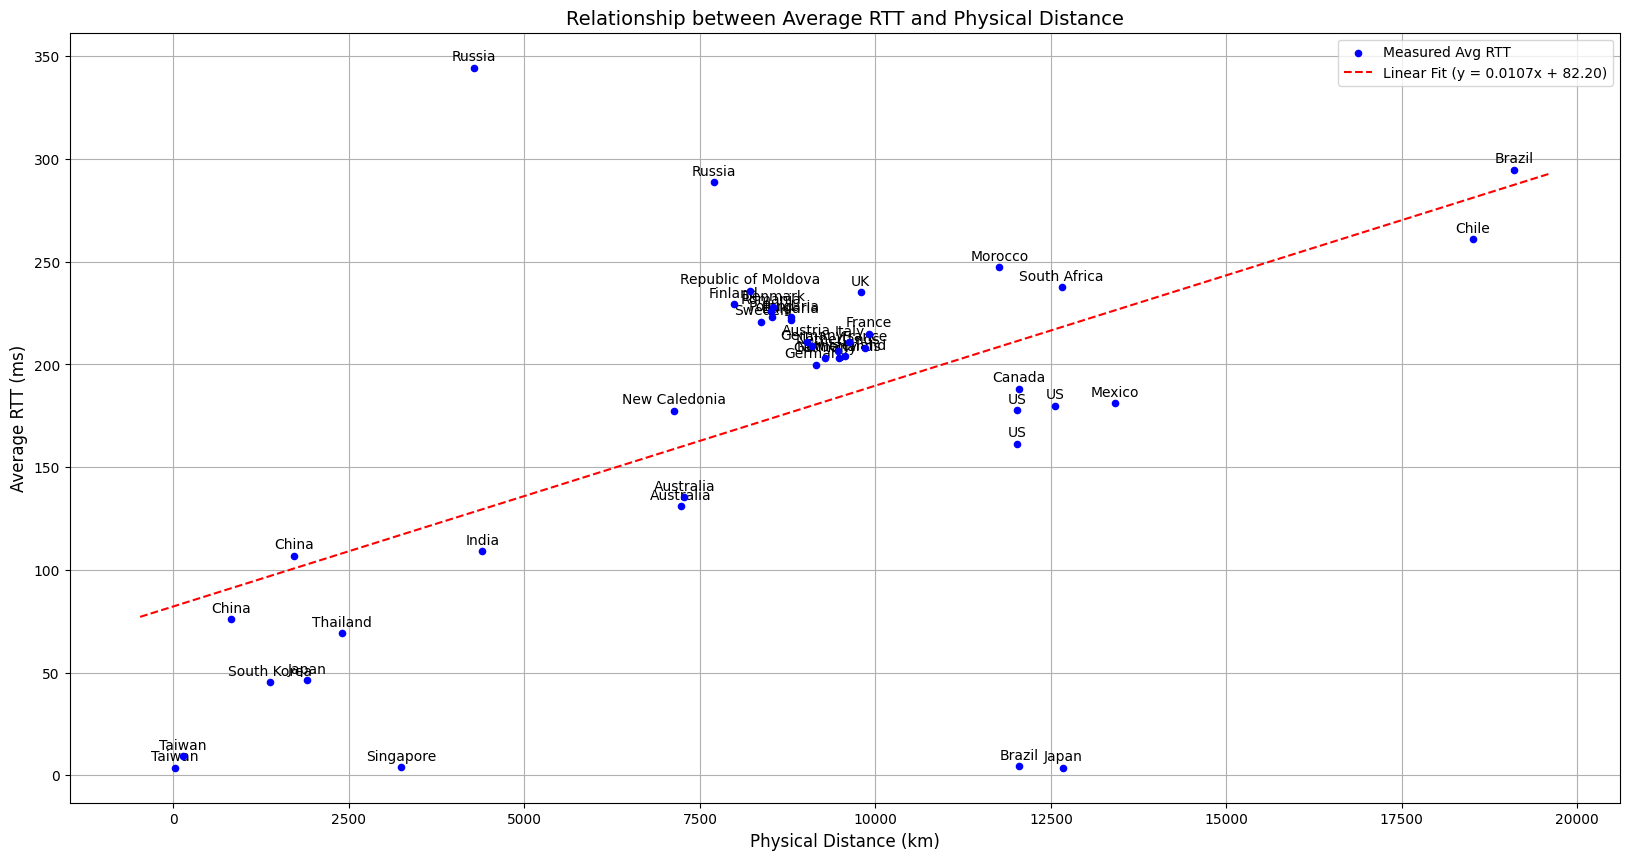

In [51]:
x = df_results['distance_km'].values
y = df_results['avg_rtt_ms'].values

# Fit y = mx + c
m, c = np.polyfit(x, y, 1)

print(f"Estimated average RTT per km (slope): {m:.5f} ms/km")
print(f"Estimated baseline delay (intercept): {c:.2f} ms\n")

# Setup the Plot
plt.figure(figsize=(20, 10))

# Plot the raw measurements
plt.scatter(x, y, color='blue', label='Measured Avg RTT', s=20, zorder=5)

# Plot the fitted line
x_line = np.linspace(min(x)-500, max(x)+500, 100)
y_line = m * x_line + c
plt.plot(x_line, y_line, color='red', linestyle='--',
         label=f'Linear Fit (y = {m:.4f}x + {c:.2f})', zorder=4)

# Annotate points with country for interpretation
for i, txt in enumerate(df_results['country']):
    plt.annotate(txt, (x[i], y[i]), textcoords="offset points", xytext=(0,5), ha='center')

plt.title('Relationship between Average RTT and Physical Distance', fontsize=14)
plt.xlabel('Physical Distance (km)', fontsize=12)
plt.ylabel('Average RTT (ms)', fontsize=12)
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

Estimated average RTT per km (slope): 0.01075 ms/km \
Estimated baseline delay (intercept): 82.20 ms

####6. Conclusion

Analysis of the Linear Fit:

By applying a linear fit ($y = mx + c$) to our data, we can map our measurements directly to the theoretical formula $RTT = \left(\frac{2}{v}\right)d + \left(\frac{2L}{C} + n\right)$:

1. **Slope ($m$ = 0.01075 ms/km):** This represents the propagation delay ($\frac{2}{v}$). For every extra kilometer of distance, our RTT increases by 0.01075 ms due to the physical speed limits.

2. **Y-Intercept ($c$ = 82.20 ms):** This is our baseline, distance-independent delay ($\frac{2L}{C} + n$). It takes about 82.20 ms just to transmit packets at the nodes and process/queue them through the routers, regardless of the distance.

The strong upward trend confirms that physical distance heavily impacts RTT. However, the scatter of points around our fitted line shows that variable routing paths and fluctuating queuing delays ($n$) also significantly affect the final time for each individual server.
